# AgriMind Phase 4: Improved ANN Fertilizer Recommendation

This is the improved paste-and-run-ready Phase 4 notebook.

Dataset path used:

```text
E:\AI Project\AgriMind_Project\datasets\Fertilizer_Recomendation_Dataset\Crop and fertilizer dataset.csv
```

This version improves accuracy by using:

- one-hot encoding for categorical features
- NPK and pH feature engineering
- duplicate and conflict checking
- train / validation / test split
- several ANN model configurations
- dropout and batch normalization
- early stopping
- learning-rate reduction
- class weights for imbalance
- automatic best-model selection
- overfitting / underfitting diagnosis
- full guideline outputs: metrics, graphs, confusion matrix, report, saved model

Important: this notebook is designed to improve accuracy, but no model can honestly guarantee 70% unless the dataset quality supports it.

In [1]:
# ============================================================
# Block 1: Import libraries and set environment
# ============================================================

import os
import sys
import json
import pickle
import subprocess
import warnings

warnings.filterwarnings("ignore")

os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("TF_NUM_INTRAOP_THREADS", "1")
os.environ.setdefault("TF_NUM_INTEROP_THREADS", "1")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow"
}

for import_name, package_name in required_packages.items():
    try:
        __import__(import_name)
    except ModuleNotFoundError:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU available: []


In [2]:
# ============================================================
# Block 2: Define exact project paths
# ============================================================

PROJECT_DIR = r"E:\AI Project\AgriMind_Project"

DATASET_PATH = r"E:\AI Project\AgriMind_Project\datasets\Fertilizer_Recomendation_Dataset\Crop and fertilizer dataset.csv"

MODEL_DIR = r"E:\AI Project\AgriMind_Project\models\phase4_ann_improved_fertilizer_recommendation"
RESULTS_DIR = r"E:\AI Project\AgriMind_Project\results\phase4_ann_improved_fertilizer_recommendation"
SCREENSHOTS_DIR = r"E:\AI Project\AgriMind_Project\screenshots\phase4_ann_improved_fertilizer_recommendation"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(SCREENSHOTS_DIR, exist_ok=True)

print("Project directory exists:", os.path.exists(PROJECT_DIR))
print("Dataset file exists:", os.path.exists(DATASET_PATH))
print("Dataset path:", DATASET_PATH)
print("Model folder:", MODEL_DIR)
print("Results folder:", RESULTS_DIR)
print("Screenshots folder:", SCREENSHOTS_DIR)

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found: {DATASET_PATH}")

Project directory exists: True
Dataset file exists: True
Dataset path: E:\AI Project\AgriMind_Project\datasets\Fertilizer_Recomendation_Dataset\Crop and fertilizer dataset.csv
Model folder: E:\AI Project\AgriMind_Project\models\phase4_ann_improved_fertilizer_recommendation
Results folder: E:\AI Project\AgriMind_Project\results\phase4_ann_improved_fertilizer_recommendation
Screenshots folder: E:\AI Project\AgriMind_Project\screenshots\phase4_ann_improved_fertilizer_recommendation


In [3]:
# ============================================================
# Block 3: Import dataset
# ============================================================

df_original = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df_original.shape)

display(df_original.head())
display(df_original.tail())

Dataset loaded successfully.
Dataset shape: (4513, 11)


,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer,Link
0,Kolhapur,Black,75,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
1,Kolhapur,Black,80,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
2,Kolhapur,Black,85,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
3,Kolhapur,Black,90,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
4,Kolhapur,Black,95,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo


,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer,Link
4508,Pune,Black,130,80,150,7.0,1400,30,Sugarcane,MOP,https://youtu.be/2t5Am0xLTOo
4509,Pune,Black,135,80,150,7.0,1400,30,Sugarcane,MOP,https://youtu.be/2t5Am0xLTOo
4510,Pune,Black,140,80,150,7.0,1400,30,Sugarcane,MOP,https://youtu.be/2t5Am0xLTOo
4511,Pune,Black,145,80,150,7.0,1400,30,Sugarcane,MOP,https://youtu.be/2t5Am0xLTOo
4512,Pune,Black,150,80,150,7.0,1400,30,Sugarcane,MOP,https://youtu.be/2t5Am0xLTOo


In [4]:
# ============================================================
# Block 4: Source of dataset and dataset characteristics
# ============================================================

DATASET_SOURCE = "Kaggle: Crop and Fertilizer Dataset for Western Maharashtra. Saved locally as Crop and fertilizer dataset.csv."

dataset_characteristics = {
    "dataset_path": DATASET_PATH,
    "dataset_source": DATASET_SOURCE,
    "number_of_rows": int(df_original.shape[0]),
    "number_of_columns": int(df_original.shape[1]),
    "column_names": list(df_original.columns),
    "total_missing_values": int(df_original.isnull().sum().sum()),
    "duplicate_rows": int(df_original.duplicated().sum())
}

print(json.dumps(dataset_characteristics, indent=4))

{
    "dataset_path": "E:\\AI Project\\AgriMind_Project\\datasets\\Fertilizer_Recomendation_Dataset\\Crop and fertilizer dataset.csv",
    "dataset_source": "Kaggle: Crop and Fertilizer Dataset for Western Maharashtra. Saved locally as Crop and fertilizer dataset.csv.",
    "number_of_rows": 4513,
    "number_of_columns": 11,
    "column_names": [
        "District_Name",
        "Soil_color",
        "Nitrogen",
        "Phosphorus",
        "Potassium",
        "pH",
        "Rainfall",
        "Temperature",
        "Crop",
        "Fertilizer",
        "Link"
    ],
    "total_missing_values": 0,
    "duplicate_rows": 0
}


In [5]:
# ============================================================
# Block 5: Dataset information and statistical summary
# ============================================================

print("Dataset information")
print("-------------------")
df_original.info()

print("\nNumerical column summary")
display(df_original.describe(include=[np.number]))

print("\nCategorical column summary")
display(df_original.describe(include=["object"]))

Dataset information
-------------------
<class 'pandas.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   District_Name  4513 non-null   str    
 1   Soil_color     4513 non-null   str    
 2   Nitrogen       4513 non-null   int64  
 3   Phosphorus     4513 non-null   int64  
 4   Potassium      4513 non-null   int64  
 5   pH             4513 non-null   float64
 6   Rainfall       4513 non-null   int64  
 7   Temperature    4513 non-null   int64  
 8   Crop           4513 non-null   str    
 9   Fertilizer     4513 non-null   str    
 10  Link           4513 non-null   str    
dtypes: float64(1), int64(5), str(5)
memory usage: 388.0 KB

Numerical column summary


,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature
count,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000
mean,95.409927,54.341901,63.595170,6.715267,819.189010,25.915134
std,38.060648,16.551991,35.691911,0.625198,251.730813,5.897328
min,20.000000,10.000000,5.000000,5.500000,300.000000,10.000000
25%,60.000000,40.000000,40.000000,6.000000,600.000000,20.000000
50%,105.000000,55.000000,55.000000,6.500000,800.000000,25.000000
75%,125.000000,65.000000,75.000000,7.000000,1000.000000,30.000000
max,150.000000,90.000000,150.000000,8.500000,1700.000000,40.000000



Categorical column summary


,District_Name,Soil_color,Crop,Fertilizer,Link
count,4513,4513,4513,4513,4513
unique,5,7,16,19,278
top,Kolhapur,Black,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
freq,1430,2260,1010,1364,1010


In [7]:
# ============================================================
# Block 6: Clean column names and remove duplicate records
# ============================================================

df = df_original.copy()

df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("/", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace(".", "_", regex=False)
)

print("Cleaned column names:")
print(list(df.columns))

rows_before = df.shape[0]
df = df.drop_duplicates()
rows_after = df.shape[0]

print("\nRows before duplicate removal:", rows_before)
print("Rows after duplicate removal:", rows_after)
print("Duplicate records removed:", rows_before - rows_after)

Cleaned column names:
['district_name', 'soil_color', 'nitrogen', 'phosphorus', 'potassium', 'ph', 'rainfall', 'temperature', 'crop', 'fertilizer', 'link']

Rows before duplicate removal: 4513
Rows after duplicate removal: 4513
Duplicate records removed: 0


In [8]:
# ============================================================
# Block 7: Detect target/output fertilizer column
# ============================================================

possible_target_keywords = [
    "fertilizer", "fertiliser", "fertilizer_name", "fertiliser_name",
    "recommendation", "recommended_fertilizer", "target", "label", "output"
]

TARGET_COLUMN = None

for col in df.columns:
    col_lower = str(col).lower()
    if any(keyword in col_lower for keyword in possible_target_keywords):
        TARGET_COLUMN = col
        break

if TARGET_COLUMN is None:
    TARGET_COLUMN = df.columns[-1]
    print("Target column not clearly detected. Last column selected as fallback.")

print("Detected target column:", TARGET_COLUMN)

target_distribution = df[TARGET_COLUMN].value_counts()
print("\nTarget class distribution:")
display(target_distribution)

if target_distribution.shape[0] < 2:
    raise ValueError("Only one fertilizer class detected. Classification needs at least 2 classes.")

Detected target column: fertilizer

Target class distribution:


fertilizer
Urea                      1364
DAP                        667
MOP                        571
19:19:19 NPK               480
SSP                        417
Magnesium Sulphate         215
10:26:26 NPK               156
50:26:26 NPK               124
Chilated Micronutrient     108
12:32:16 NPK               106
Ferrous Sulphate            68
13:32:26 NPK                66
Ammonium Sulphate           50
10:10:10 NPK                50
Hydrated Lime               25
White Potash                19
20:20:20 NPK                15
18:46:00 NPK                 6
Sulphur                      6
Name: count, dtype: int64

In [9]:
# ============================================================
# Block 8: Handle missing values
# ============================================================

missing_before = df.isnull().sum()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()
        df[col] = df[col].fillna(mode_value[0] if len(mode_value) > 0 else "Unknown")

missing_after = df.isnull().sum()

missing_report = pd.DataFrame({
    "Missing_Before": missing_before,
    "Missing_After": missing_after
})

display(missing_report)

,Missing_Before,Missing_After
district_name,0,0
soil_color,0,0
nitrogen,0,0
phosphorus,0,0
potassium,0,0
ph,0,0
rainfall,0,0
temperature,0,0
crop,0,0
fertilizer,0,0


In [10]:
# ============================================================
# Block 9: Treat outliers in numerical feature columns
# ============================================================

numeric_feature_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns.tolist()
    if col != TARGET_COLUMN
]

outlier_report = []

for col in numeric_feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    outliers_after = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_report.append({
        "Column": col,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outliers_Before": int(outliers_before),
        "Outliers_After": int(outliers_after)
    })

outlier_report_df = pd.DataFrame(outlier_report)
display(outlier_report_df)

,Column,Lower_Bound,Upper_Bound,Outliers_Before,Outliers_After
0,nitrogen,-37.5,222.5,0,0
1,phosphorus,2.5,102.5,0,0
2,potassium,-12.5,127.5,495,0
3,ph,4.5,8.5,0,0
4,rainfall,0.0,1600.0,9,0
5,temperature,5.0,45.0,0,0


In [11]:
# ============================================================
# Block 10: Feature selection approach
# ============================================================

drop_keywords = ["link", "url", "id", "index", "serial", "no", "number"]

feature_columns = []

for col in df.columns:
    if col == TARGET_COLUMN:
        continue

    col_lower = str(col).lower()

    if any(keyword == col_lower or keyword in col_lower for keyword in drop_keywords):
        continue

    feature_columns.append(col)

print("Initial selected feature columns:")
for col in feature_columns:
    print("-", col)

print("\nTarget/output column:", TARGET_COLUMN)

Initial selected feature columns:
- district_name
- soil_color
- nitrogen
- phosphorus
- potassium
- ph
- rainfall
- temperature
- crop

Target/output column: fertilizer


Total unique feature combinations: 4510
Conflicting feature combinations: 3


,district_name,soil_color,nitrogen,phosphorus,potassium,ph,rainfall,temperature,crop,fertilizer
399,Kolhapur,Dark Brown,100,40,40.0,6.0,500,15,Wheat,2
410,Kolhapur,Dark Brown,100,45,45.0,6.5,600,20,Wheat,2
1916,Sangli,Black,25,20,40.0,5.5,1500,20,Turmeric,2


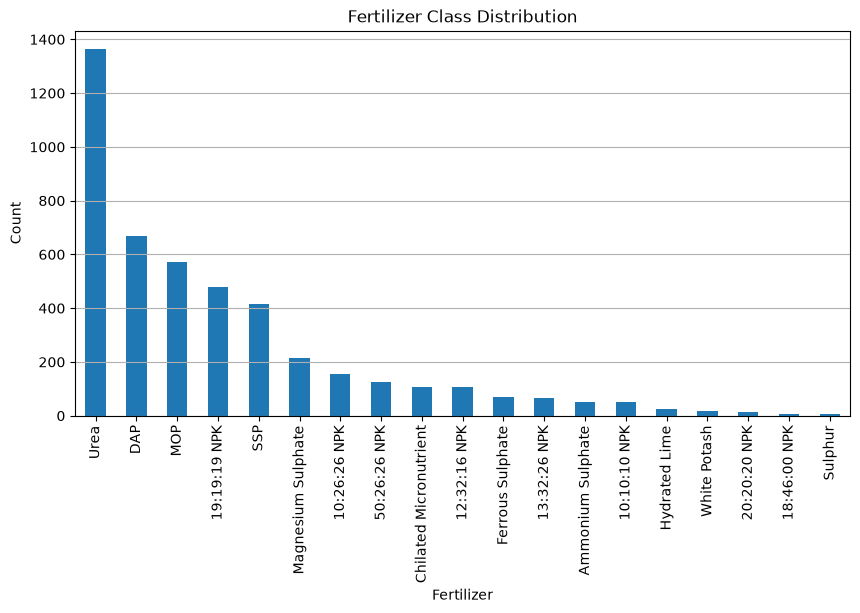

Class distribution graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase4_ann_improved_fertilizer_recommendation\phase4_class_distribution.png


In [12]:
# ============================================================
# Block 11: Dataset conflict and class-balance check
# ============================================================

# If the same input condition has different fertilizer labels, the model may struggle.
conflict_check = (
    df[feature_columns + [TARGET_COLUMN]]
    .groupby(feature_columns)[TARGET_COLUMN]
    .nunique()
    .reset_index()
)

conflicting_rows = conflict_check[conflict_check[TARGET_COLUMN] > 1]

print("Total unique feature combinations:", conflict_check.shape[0])
print("Conflicting feature combinations:", conflicting_rows.shape[0])

if conflicting_rows.shape[0] > 0:
    print("Warning: Same input conditions have multiple fertilizer outputs.")
    display(conflicting_rows.head())
else:
    print("No major duplicate-label conflict found.")

class_distribution = df[TARGET_COLUMN].value_counts()

plt.figure(figsize=(10, 5))
class_distribution.plot(kind="bar")
plt.title("Fertilizer Class Distribution")
plt.xlabel("Fertilizer")
plt.ylabel("Count")
plt.grid(axis="y")
class_distribution_graph_path = os.path.join(SCREENSHOTS_DIR, "phase4_class_distribution.png")
plt.savefig(class_distribution_graph_path, dpi=300, bbox_inches="tight")
plt.show()

print("Class distribution graph saved at:", class_distribution_graph_path)

In [25]:
# ============================================================
# Block 12: Feature engineering to improve accuracy - BETTER VERSION
# ============================================================

# This block safely handles NPK values whether they are:
# 1. numeric values, or
# 2. text values such as Low, Medium, High

df_model = df.copy()

def find_col_by_keywords(columns, keywords):
    for col in columns:
        col_lower = col.lower()
        if any(keyword in col_lower for keyword in keywords):
            return col
    return None

nitrogen_col = find_col_by_keywords(df_model.columns, ["nitrogen"])
phosphorus_col = find_col_by_keywords(df_model.columns, ["phosphorus", "phosphorous"])
potassium_col = find_col_by_keywords(df_model.columns, ["potassium"])
ph_col = find_col_by_keywords(df_model.columns, ["ph"])
crop_col = find_col_by_keywords(df_model.columns, ["crop"])
soil_col = find_col_by_keywords(df_model.columns, ["soil"])

print("Detected nitrogen column:", nitrogen_col)
print("Detected phosphorus column:", phosphorus_col)
print("Detected potassium column:", potassium_col)
print("Detected pH column:", ph_col)
print("Detected crop column:", crop_col)
print("Detected soil column:", soil_col)

# Mapping for text nutrient levels
nutrient_level_map = {
    "low": 0,
    "medium": 1,
    "moderate": 1,
    "high": 2,
    "very low": 0,
    "very high": 3
}

def convert_nutrient_column(series):
    # First try text mapping
    mapped = series.astype(str).str.strip().str.lower().map(nutrient_level_map)

    # Then try numeric conversion
    numeric = pd.to_numeric(series, errors="coerce")

    # Use numeric values if available, otherwise use mapped values
    final = numeric.fillna(mapped)

    # Fill remaining missing values with median or 0
    if final.isnull().sum() > 0:
        if final.dropna().shape[0] > 0:
            final = final.fillna(final.median())
        else:
            final = final.fillna(0)

    return final

eps = 1e-6

# Convert NPK columns properly
if nitrogen_col and phosphorus_col and potassium_col:
    df_model[nitrogen_col] = convert_nutrient_column(df_model[nitrogen_col])
    df_model[phosphorus_col] = convert_nutrient_column(df_model[phosphorus_col])
    df_model[potassium_col] = convert_nutrient_column(df_model[potassium_col])

    df_model["npk_total"] = (
        df_model[nitrogen_col]
        + df_model[phosphorus_col]
        + df_model[potassium_col]
    )

    df_model["n_to_p_ratio"] = df_model[nitrogen_col] / (df_model[phosphorus_col] + eps)
    df_model["n_to_k_ratio"] = df_model[nitrogen_col] / (df_model[potassium_col] + eps)
    df_model["p_to_k_ratio"] = df_model[phosphorus_col] / (df_model[potassium_col] + eps)

    print("Added NPK engineered features.")
else:
    print("NPK columns were not fully detected. NPK engineered features skipped.")

# Convert pH safely
if ph_col:
    df_model[ph_col] = pd.to_numeric(df_model[ph_col], errors="coerce")

    if df_model[ph_col].isnull().sum() > 0:
        df_model[ph_col] = df_model[ph_col].fillna(df_model[ph_col].median())

    df_model["ph_category"] = pd.cut(
        df_model[ph_col],
        bins=[-999, 6.0, 7.5, 999],
        labels=["acidic", "neutral", "alkaline"]
    ).astype(str)

    print("Added pH category feature.")
else:
    print("pH column was not detected. pH category skipped.")

# Add crop-soil combination
if crop_col and soil_col:
    df_model["crop_soil_combination"] = (
        df_model[crop_col].astype(str)
        + "_"
        + df_model[soil_col].astype(str)
    )

    print("Added crop-soil combination feature.")
else:
    print("Crop-soil combination skipped.")

# Recreate feature columns after feature engineering
feature_columns = []

for col in df_model.columns:
    if col == TARGET_COLUMN:
        continue

    col_lower = str(col).lower()

    if any(keyword == col_lower or keyword in col_lower for keyword in drop_keywords):
        continue

    feature_columns.append(col)

print("\nFinal selected feature columns:")
for col in feature_columns:
    print("-", col)

X_raw = df_model[feature_columns].copy()
y_raw = df_model[TARGET_COLUMN].copy()

display(X_raw.head())

Detected nitrogen column: nitrogen
Detected phosphorus column: phosphorus
Detected potassium column: potassium
Detected pH column: phosphorus
Detected crop column: crop
Detected soil column: soil_color
Added NPK engineered features.
Added pH category feature.
Added crop-soil combination feature.

Final selected feature columns:
- district_name
- soil_color
- nitrogen
- phosphorus
- potassium
- ph
- rainfall
- temperature
- crop
- npk_total
- n_to_p_ratio
- n_to_k_ratio
- p_to_k_ratio
- ph_category
- crop_soil_combination


,district_name,soil_color,nitrogen,phosphorus,potassium,ph,rainfall,temperature,crop,npk_total,n_to_p_ratio,n_to_k_ratio,p_to_k_ratio,ph_category,crop_soil_combination
0,Kolhapur,Black,75,50,100.0,6.5,1000,20,Sugarcane,225.0,1.5,0.75,0.5,alkaline,Sugarcane_Black
1,Kolhapur,Black,80,50,100.0,6.5,1000,20,Sugarcane,230.0,1.6,0.80,0.5,alkaline,Sugarcane_Black
2,Kolhapur,Black,85,50,100.0,6.5,1000,20,Sugarcane,235.0,1.7,0.85,0.5,alkaline,Sugarcane_Black
3,Kolhapur,Black,90,50,100.0,6.5,1000,20,Sugarcane,240.0,1.8,0.90,0.5,alkaline,Sugarcane_Black
4,Kolhapur,Black,95,50,100.0,6.5,1000,20,Sugarcane,245.0,1.9,0.95,0.5,alkaline,Sugarcane_Black


In [26]:
# ============================================================
# Block 13: Handle categorical variables using One-Hot Encoding
# ============================================================

# One-hot encoding is better for columns such as crop, soil, district, pH category, etc.

X_encoded = pd.get_dummies(X_raw, drop_first=False)

# Ensure all encoded values are numeric
for col in X_encoded.columns:
    X_encoded[col] = pd.to_numeric(X_encoded[col], errors="coerce").fillna(0)

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y_raw.astype(str))

class_names = list(target_encoder.classes_)
num_classes = len(class_names)

print("Input feature shape after one-hot encoding:", X_encoded.shape)
print("Number of fertilizer classes:", num_classes)

print("\nFertilizer classes:")
for i, name in enumerate(class_names):
    print(i, name)

display(X_encoded.head())

Input feature shape after one-hot encoding: (4513, 71)
Number of fertilizer classes: 19

Fertilizer classes:
0 10:10:10 NPK
1 10:26:26 NPK
2 12:32:16 NPK
3 13:32:26 NPK
4 18:46:00 NPK
5 19:19:19 NPK
6 20:20:20 NPK
7 50:26:26 NPK
8 Ammonium Sulphate
9 Chilated Micronutrient
10 DAP
11 Ferrous Sulphate
12 Hydrated Lime
13 MOP
14 Magnesium Sulphate
15 SSP
16 Sulphur
17 Urea
18 White Potash


,nitrogen,phosphorus,potassium,ph,rainfall,temperature,npk_total,n_to_p_ratio,n_to_k_ratio,p_to_k_ratio,...,crop_soil_combination_Tur_Red,crop_soil_combination_Tur_Reddish Brown,crop_soil_combination_Turmeric_Black,crop_soil_combination_Turmeric_Red,crop_soil_combination_Urad_Black,crop_soil_combination_Urad_Dark Brown,crop_soil_combination_Wheat_Black,crop_soil_combination_Wheat_Dark Brown,crop_soil_combination_Wheat_Red,crop_soil_combination_Wheat_Reddish Brown
0,75,50,100.0,6.5,1000,20,225.0,1.5,0.75,0.5,...,False,False,False,False,False,False,False,False,False,False
1,80,50,100.0,6.5,1000,20,230.0,1.6,0.80,0.5,...,False,False,False,False,False,False,False,False,False,False
2,85,50,100.0,6.5,1000,20,235.0,1.7,0.85,0.5,...,False,False,False,False,False,False,False,False,False,False
3,90,50,100.0,6.5,1000,20,240.0,1.8,0.90,0.5,...,False,False,False,False,False,False,False,False,False,False
4,95,50,100.0,6.5,1000,20,245.0,1.9,0.95,0.5,...,False,False,False,False,False,False,False,False,False,False


In [27]:
# ============================================================
# Block 14: Feature scaling
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Feature matrix shape after scaling:", X_scaled.shape)
print("Target vector shape:", y_encoded.shape)

Feature matrix shape after scaling: (4513, 71)
Target vector shape: (4513,)


In [29]:
# ============================================================
# Block 15: Improved train / validation / test split - FIXED VERSION
# ============================================================

# Split:
# 80% training
# 10% validation
# 10% testing
#
# Important:
# Some fertilizer classes have very few samples.
# Therefore, we use stratify only in the first split if possible.
# The second split is done without stratify to avoid class-count errors.

class_counts = pd.Series(y_encoded).value_counts()

print("Class counts:")
display(class_counts)

# Stratify only if every class has at least 2 samples
can_stratify_first_split = (num_classes > 1) and (class_counts.min() >= 2)

if can_stratify_first_split:
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_scaled,
        y_encoded,
        test_size=0.20,
        random_state=42,
        stratify=y_encoded
    )
else:
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_scaled,
        y_encoded,
        test_size=0.20,
        random_state=42
    )

# Do NOT stratify the second split because rare classes may have only 1 sample in y_temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Can use stratified first split:", can_stratify_first_split)
print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of input features:", X_train.shape[1])
print("Number of output classes:", num_classes)

print("\nTraining class distribution:")
display(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class distribution:")
display(pd.Series(y_val).value_counts().sort_index())

print("\nTesting class distribution:")
display(pd.Series(y_test).value_counts().sort_index())

Class counts:


17    1364
10     667
13     571
5      480
15     417
14     215
1      156
7      124
9      108
2      106
11      68
3       66
8       50
0       50
12      25
18      19
6       15
4        6
16       6
Name: count, dtype: int64

Can use stratified first split: True
Training samples: 3610
Validation samples: 451
Testing samples: 452
Number of input features: 71
Number of output classes: 19

Training class distribution:


0       40
1      125
2       85
3       53
4        5
5      384
6       12
7       99
8       40
9       86
10     533
11      54
12      20
13     457
14     172
15     334
16       5
17    1091
18      15
Name: count, dtype: int64


Validation class distribution:


0       5
1      12
2      13
3       8
4       1
5      46
6       3
7      14
8       4
9       7
10     72
11      6
13     65
14     18
15     42
17    134
18      1
Name: count, dtype: int64


Testing class distribution:


0       5
1      19
2       8
3       5
5      50
7      11
8       6
9      15
10     62
11      8
12      5
13     49
14     25
15     41
16      1
17    139
18      3
Name: count, dtype: int64

In [30]:
# ============================================================
# Block 16: Define stronger ANN model configurations
# ============================================================

def build_ann_model(input_dim, num_classes, config_name):
    if config_name == "strong_1":
        layers = [
            tf.keras.layers.Input(shape=(input_dim,)),

            tf.keras.layers.Dense(512, activation="relu"),
            tf.keras.layers.BatchNormalization(),

            tf.keras.layers.Dense(256, activation="relu"),
            tf.keras.layers.BatchNormalization(),

            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dropout(0.05),

            tf.keras.layers.Dense(64, activation="relu"),

            tf.keras.layers.Dense(num_classes, activation="softmax")
        ]

    elif config_name == "strong_2":
        layers = [
            tf.keras.layers.Input(shape=(input_dim,)),

            tf.keras.layers.Dense(256, activation="relu"),
            tf.keras.layers.BatchNormalization(),

            tf.keras.layers.Dense(256, activation="relu"),
            tf.keras.layers.BatchNormalization(),

            tf.keras.layers.Dense(128, activation="relu"),

            tf.keras.layers.Dense(64, activation="relu"),

            tf.keras.layers.Dense(num_classes, activation="softmax")
        ]

    elif config_name == "strong_3":
        layers = [
            tf.keras.layers.Input(shape=(input_dim,)),

            tf.keras.layers.Dense(512, activation="relu"),

            tf.keras.layers.Dense(256, activation="relu"),

            tf.keras.layers.Dense(128, activation="relu"),

            tf.keras.layers.Dense(64, activation="relu"),

            tf.keras.layers.Dense(32, activation="relu"),

            tf.keras.layers.Dense(num_classes, activation="softmax")
        ]

    else:
        raise ValueError("Unknown config name")

    model = tf.keras.Sequential(layers)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model_configs = ["strong_1", "strong_2", "strong_3"]

print("Model configurations to train:", model_configs)

Model configurations to train: ['strong_1', 'strong_2', 'strong_3']


In [31]:
# ============================================================
# Block 17: Train stronger ANN models and select best validation accuracy
# ============================================================

EPOCHS = 300
BATCH_SIZE = 8

classes_present = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=y_train
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes_present, class_weights_array)
}

print("Class weights:")
print(class_weights)

trained_models = {}
histories = {}
validation_scores = []

for config_name in model_configs:
    print("\n===================================================")
    print("Training ANN config:", config_name)
    print("===================================================")

    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    model = build_ann_model(
        input_dim=X_train.shape[1],
        num_classes=num_classes,
        config_name=config_name
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=40,
        mode="max",
        restore_best_weights=True
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=15,
        min_lr=0.000001
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping, reduce_lr],
        class_weight=class_weights,
        verbose=1
    )

    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)

    trained_models[config_name] = model
    histories[config_name] = history

    validation_scores.append({
        "Config": config_name,
        "Train_Loss": train_loss,
        "Train_Accuracy": train_accuracy,
        "Validation_Loss": val_loss,
        "Validation_Accuracy": val_accuracy,
        "Completed_Epochs": len(history.history["loss"])
    })

validation_scores_df = pd.DataFrame(validation_scores)
display(validation_scores_df)

validation_scores_path = os.path.join(
    RESULTS_DIR,
    "phase4_ann_validation_model_selection.csv"
)

validation_scores_df.to_csv(validation_scores_path, index=False)

print("Validation model selection saved at:", validation_scores_path)

Class weights:
{0: 4.75, 1: 1.52, 2: 2.235294117647059, 3: 3.5849056603773586, 4: 38.0, 5: 0.4947916666666667, 6: 15.833333333333334, 7: 1.9191919191919191, 8: 4.75, 9: 2.2093023255813953, 10: 0.35647279549718575, 11: 3.5185185185185186, 12: 9.5, 13: 0.41575492341356673, 14: 1.1046511627906976, 15: 0.5688622754491018, 16: 38.0, 17: 0.17415215398716774, 18: 12.666666666666666}

Training ANN config: strong_1
Epoch 1/300
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3695 - loss: 1.5141 - val_accuracy: 0.3814 - val_loss: 1.7033 - learning_rate: 0.0010
Epoch 2/300
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4163 - loss: 1.1961 - val_accuracy: 0.3947 - val_loss: 1.6605 - learning_rate: 0.0010
Epoch 3/300
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4249 - loss: 0.9210 - val_accuracy: 0.4013 - val_loss: 1.6550 - learning_rate: 0.0010
Epoch 4/300
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4335 - loss: 0.8680 - val_accuracy: 0.3969 - val_loss: 1.5303 - 

,Config,Train_Loss,Train_Accuracy,Validation_Loss,Validation_Accuracy,Completed_Epochs
0,strong_1,1.779922,0.458726,2.165980,0.436807,70
1,strong_2,2.227158,0.474792,2.561355,0.447894,74
2,strong_3,0.016529,0.993075,0.073115,0.988914,191


Validation model selection saved at: E:\AI Project\AgriMind_Project\results\phase4_ann_improved_fertilizer_recommendation\phase4_ann_validation_model_selection.csv


In [32]:
# ============================================================
# Block 18: Select best ANN model
# ============================================================

best_row = validation_scores_df.sort_values(by="Validation_Accuracy", ascending=False).iloc[0]

BEST_CONFIG = best_row["Config"]
ann_model = trained_models[BEST_CONFIG]
history = histories[BEST_CONFIG]

print("Best ANN configuration:", BEST_CONFIG)
print(best_row)

Best ANN configuration: strong_3
Config                 strong_3
Train_Loss             0.016529
Train_Accuracy         0.993075
Validation_Loss        0.073115
Validation_Accuracy    0.988914
Completed_Epochs            191
Name: 2, dtype: object


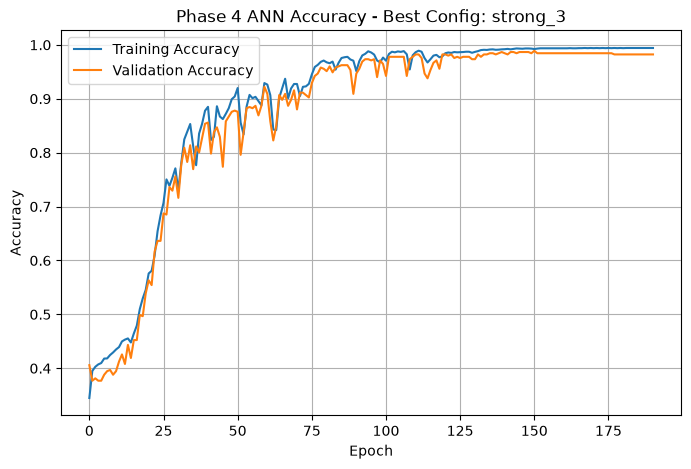

Accuracy graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase4_ann_improved_fertilizer_recommendation\phase4_improved_ann_accuracy_graph.png


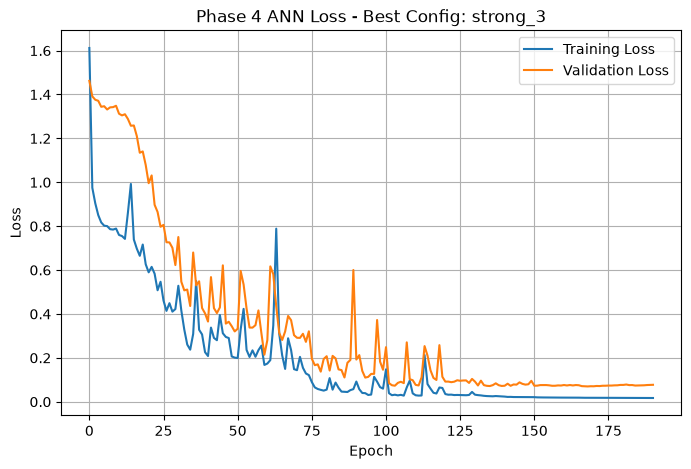

Loss graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase4_ann_improved_fertilizer_recommendation\phase4_improved_ann_loss_graph.png


In [33]:
# ============================================================
# Block 19: Plot training and validation accuracy/loss for best model
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title(f"Phase 4 ANN Accuracy - Best Config: {BEST_CONFIG}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

accuracy_graph_path = os.path.join(SCREENSHOTS_DIR, "phase4_improved_ann_accuracy_graph.png")
plt.savefig(accuracy_graph_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy graph saved at:", accuracy_graph_path)

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title(f"Phase 4 ANN Loss - Best Config: {BEST_CONFIG}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

loss_graph_path = os.path.join(SCREENSHOTS_DIR, "phase4_improved_ann_loss_graph.png")
plt.savefig(loss_graph_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss graph saved at:", loss_graph_path)

In [34]:
# ============================================================
# Block 20: Check overfitting and underfitting
# ============================================================

train_loss, train_accuracy = ann_model.evaluate(X_train, y_train, verbose=0)
val_loss, val_accuracy = ann_model.evaluate(X_val, y_val, verbose=0)

loss_gap = val_loss - train_loss
accuracy_gap = train_accuracy - val_accuracy

if train_accuracy < 0.60 and val_accuracy < 0.60:
    fit_status = "Possible underfitting: both training and validation accuracy are low."
elif accuracy_gap > 0.20 and train_accuracy > 0.80:
    fit_status = "Possible overfitting: training accuracy is much higher than validation accuracy."
else:
    fit_status = "No strong overfitting/underfitting sign based on train-validation values."

fit_check = pd.DataFrame([{
    "Best_Config": BEST_CONFIG,
    "Training_Loss": train_loss,
    "Validation_Loss": val_loss,
    "Training_Accuracy": train_accuracy,
    "Validation_Accuracy": val_accuracy,
    "Loss_Gap": loss_gap,
    "Accuracy_Gap": accuracy_gap,
    "Diagnosis": fit_status
}])

display(fit_check)

fit_check_path = os.path.join(RESULTS_DIR, "phase4_overfitting_underfitting_check.csv")
fit_check.to_csv(fit_check_path, index=False)

print("Overfitting/underfitting check saved at:", fit_check_path)

,Best_Config,Training_Loss,Validation_Loss,Training_Accuracy,Validation_Accuracy,Loss_Gap,Accuracy_Gap,Diagnosis
0,strong_3,0.016529,0.073115,0.993075,0.988914,0.056586,0.004161,No strong overfitting/underfitting sign based ...


Overfitting/underfitting check saved at: E:\AI Project\AgriMind_Project\results\phase4_ann_improved_fertilizer_recommendation\phase4_overfitting_underfitting_check.csv


In [35]:
# ============================================================
# Block 21: Evaluate best ANN model on test data
# ============================================================

test_loss, test_accuracy = ann_model.evaluate(X_test, y_test, verbose=0)

print("ANN Test Loss:", test_loss)
print("ANN Test Accuracy:", test_accuracy)

ANN Test Loss: 0.16542138159275055
ANN Test Accuracy: 0.9845132827758789


In [36]:
# ============================================================
# Block 22: Performance metrics and classification report
# ============================================================

y_pred_probs = ann_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

ann_accuracy = accuracy_score(y_test, y_pred)
ann_precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
ann_recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
ann_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

# Top-3 accuracy is useful when fertilizer classes are chemically similar.
if num_classes >= 3:
    ann_top3_accuracy = top_k_accuracy_score(
        y_test,
        y_pred_probs,
        k=3,
        labels=np.arange(num_classes)
    )
else:
    ann_top3_accuracy = np.nan

print("Final Improved ANN Fertilizer Recommendation Evaluation")
print("-------------------------------------------------------")
print("Accuracy      :", ann_accuracy)
print("Precision     :", ann_precision)
print("Recall        :", ann_recall)
print("F1-score      :", ann_f1)
print("Top-3 Accuracy:", ann_top3_accuracy)

print("\nDetailed Classification Report")
print(classification_report(
    y_test,
    y_pred,
    labels=range(num_classes),
    target_names=class_names,
    zero_division=0
))

Final Improved ANN Fertilizer Recommendation Evaluation
-------------------------------------------------------
Accuracy      : 0.9845132743362832
Precision     : 0.987924041297935
Recall        : 0.9845132743362832
F1-score      : 0.9852794880772863
Top-3 Accuracy: 0.9977876106194691

Detailed Classification Report
                        precision    recall  f1-score   support

          10:10:10 NPK       1.00      1.00      1.00         5
          10:26:26 NPK       1.00      1.00      1.00        19
          12:32:16 NPK       1.00      1.00      1.00         8
          13:32:26 NPK       1.00      1.00      1.00         5
          18:46:00 NPK       0.00      0.00      0.00         0
          19:19:19 NPK       1.00      0.98      0.99        50
          20:20:20 NPK       0.00      0.00      0.00         0
          50:26:26 NPK       1.00      1.00      1.00        11
     Ammonium Sulphate       1.00      1.00      1.00         6
Chilated Micronutrient       1.00      1.

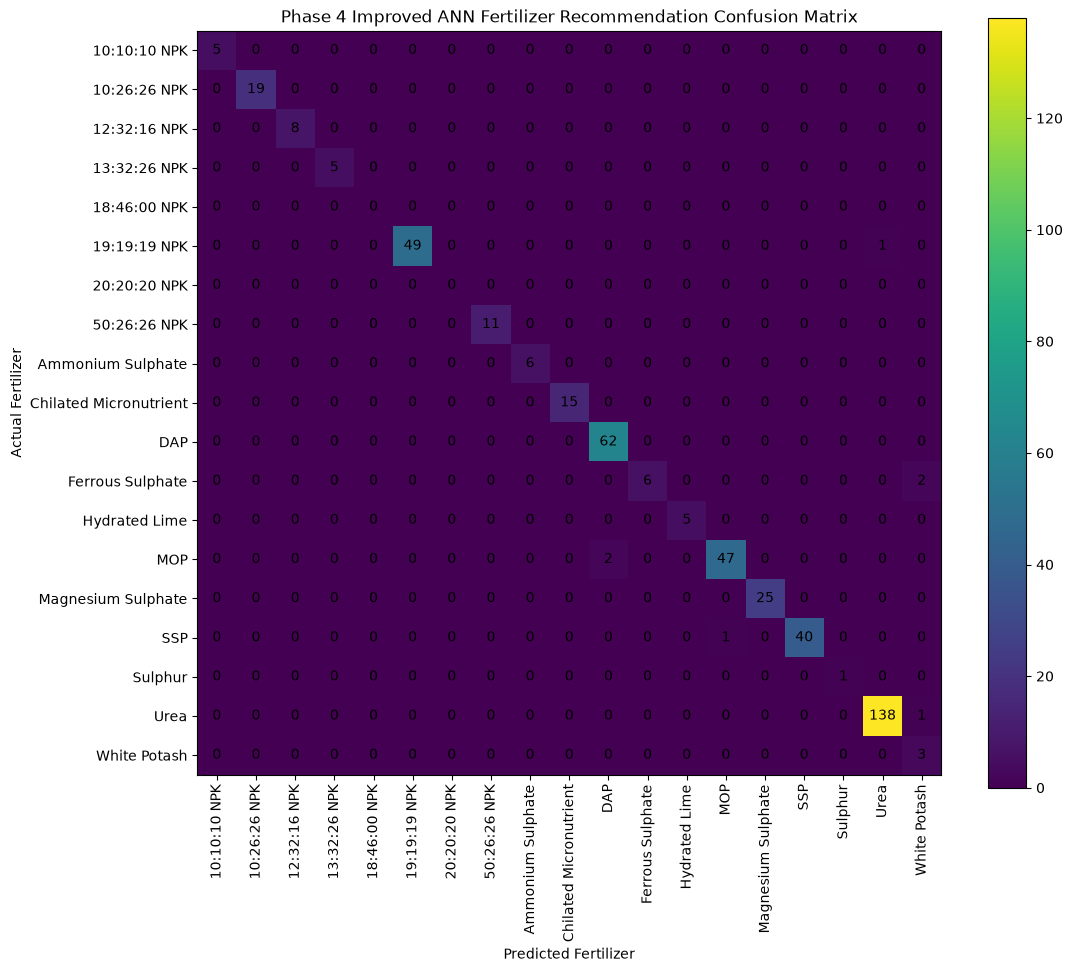

Confusion matrix saved at: E:\AI Project\AgriMind_Project\screenshots\phase4_ann_improved_fertilizer_recommendation\phase4_improved_ann_confusion_matrix.png


In [37]:
# ============================================================
# Block 23: Confusion matrix visualization
# ============================================================

cm = confusion_matrix(y_test, y_pred, labels=range(num_classes))

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.title("Phase 4 Improved ANN Fertilizer Recommendation Confusion Matrix")
plt.xlabel("Predicted Fertilizer")
plt.ylabel("Actual Fertilizer")
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

confusion_matrix_path = os.path.join(SCREENSHOTS_DIR, "phase4_improved_ann_confusion_matrix.png")
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved at:", confusion_matrix_path)

In [38]:
# ============================================================
# Block 24: Show multiple sample predictions
# ============================================================

num_samples = min(20, len(X_test))

sample_results = []

for sample_index in range(num_samples):
    sample_input = X_test[sample_index].reshape(1, -1)
    sample_actual_label = y_test[sample_index]

    sample_prediction_probs = ann_model.predict(sample_input, verbose=0)
    sample_predicted_label = np.argmax(sample_prediction_probs, axis=1)[0]
    confidence = np.max(sample_prediction_probs) * 100

    actual_fertilizer = target_encoder.inverse_transform([sample_actual_label])[0]
    predicted_fertilizer = target_encoder.inverse_transform([sample_predicted_label])[0]

    top3_indices = np.argsort(sample_prediction_probs[0])[-3:][::-1]
    top3_fertilizers = target_encoder.inverse_transform(top3_indices)

    sample_results.append({
        "Sample": sample_index + 1,
        "Actual Fertilizer": actual_fertilizer,
        "Predicted Fertilizer": predicted_fertilizer,
        "Confidence (%)": round(confidence, 2),
        "Top 3 Suggestions": ", ".join(top3_fertilizers),
        "Correct": actual_fertilizer == predicted_fertilizer
    })

sample_results_df = pd.DataFrame(sample_results)
display(sample_results_df)

sample_results_path = os.path.join(RESULTS_DIR, "phase4_sample_predictions.csv")
sample_results_df.to_csv(sample_results_path, index=False)

print("Sample predictions saved at:", sample_results_path)

,Sample,Actual Fertilizer,Predicted Fertilizer,Confidence (%),Top 3 Suggestions,Correct
0,1,Urea,Urea,100.000000,"Urea, DAP, SSP",True
1,2,DAP,DAP,100.000000,"DAP, MOP, Urea",True
2,3,Ferrous Sulphate,White Potash,70.129997,"White Potash, Ferrous Sulphate, Urea",False
3,4,19:19:19 NPK,19:19:19 NPK,100.000000,"19:19:19 NPK, Urea, SSP",True
4,5,Urea,Urea,100.000000,"Urea, 19:19:19 NPK, SSP",True
5,6,12:32:16 NPK,12:32:16 NPK,100.000000,"12:32:16 NPK, DAP, Magnesium Sulphate",True
6,7,MOP,DAP,82.160004,"DAP, MOP, Urea",False
7,8,10:26:26 NPK,10:26:26 NPK,100.000000,"10:26:26 NPK, Urea, SSP",True
8,9,SSP,SSP,100.000000,"SSP, MOP, Urea",True
9,10,DAP,DAP,100.000000,"DAP, 13:32:26 NPK, Magnesium Sulphate",True


Sample predictions saved at: E:\AI Project\AgriMind_Project\results\phase4_ann_improved_fertilizer_recommendation\phase4_sample_predictions.csv


In [39]:
# ============================================================
# Block 25: Save trained model and preprocessing objects
# ============================================================

model_path = os.path.join(MODEL_DIR, "agrimind_phase4_improved_ann_fertilizer_recommendation.keras")
ann_model.save(model_path)

scaler_path = os.path.join(MODEL_DIR, "phase4_feature_scaler.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

target_encoder_path = os.path.join(MODEL_DIR, "phase4_target_encoder.pkl")
with open(target_encoder_path, "wb") as f:
    pickle.dump(target_encoder, f)

feature_columns_path = os.path.join(MODEL_DIR, "phase4_feature_columns.json")
with open(feature_columns_path, "w") as f:
    json.dump(feature_columns, f, indent=4)

encoded_columns_path = os.path.join(MODEL_DIR, "phase4_encoded_feature_columns.json")
with open(encoded_columns_path, "w") as f:
    json.dump(list(X_encoded.columns), f, indent=4)

class_names_path = os.path.join(MODEL_DIR, "phase4_class_names.json")
with open(class_names_path, "w") as f:
    json.dump(class_names, f, indent=4)

metadata = {
    "phase": "Phase 4",
    "module": "Improved ANN Fertilizer Recommendation",
    "dataset_path": DATASET_PATH,
    "dataset_source": DATASET_SOURCE,
    "target_column": TARGET_COLUMN,
    "best_config": BEST_CONFIG,
    "feature_columns": feature_columns,
    "encoded_feature_count": int(X_encoded.shape[1]),
    "class_names": class_names,
    "model_type": "Artificial Neural Network",
    "split": "80/10/10 train-validation-test",
    "accuracy": float(ann_accuracy),
    "top3_accuracy": None if pd.isna(ann_top3_accuracy) else float(ann_top3_accuracy)
}

metadata_path = os.path.join(MODEL_DIR, "phase4_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("ANN model saved at:", model_path)
print("Scaler saved at:", scaler_path)
print("Target encoder saved at:", target_encoder_path)
print("Feature columns saved at:", feature_columns_path)
print("Encoded feature columns saved at:", encoded_columns_path)
print("Class names saved at:", class_names_path)
print("Metadata saved at:", metadata_path)

ANN model saved at: E:\AI Project\AgriMind_Project\models\phase4_ann_improved_fertilizer_recommendation\agrimind_phase4_improved_ann_fertilizer_recommendation.keras
Scaler saved at: E:\AI Project\AgriMind_Project\models\phase4_ann_improved_fertilizer_recommendation\phase4_feature_scaler.pkl
Target encoder saved at: E:\AI Project\AgriMind_Project\models\phase4_ann_improved_fertilizer_recommendation\phase4_target_encoder.pkl
Feature columns saved at: E:\AI Project\AgriMind_Project\models\phase4_ann_improved_fertilizer_recommendation\phase4_feature_columns.json
Encoded feature columns saved at: E:\AI Project\AgriMind_Project\models\phase4_ann_improved_fertilizer_recommendation\phase4_encoded_feature_columns.json
Class names saved at: E:\AI Project\AgriMind_Project\models\phase4_ann_improved_fertilizer_recommendation\phase4_class_names.json
Metadata saved at: E:\AI Project\AgriMind_Project\models\phase4_ann_improved_fertilizer_recommendation\phase4_metadata.json


In [40]:
# ============================================================
# Block 26: Save results CSV
# ============================================================

phase4_results = pd.DataFrame([{
    "Phase": "Phase 4",
    "Module": "Improved ANN Fertilizer Recommendation",
    "Dataset": "Crop and Fertilizer Dataset for Western Maharashtra",
    "Best_Config": BEST_CONFIG,
    "Model": "Artificial Neural Network",
    "Accuracy": ann_accuracy,
    "Precision": ann_precision,
    "Recall": ann_recall,
    "F1_score": ann_f1,
    "Top_3_Accuracy": ann_top3_accuracy,
    "Test_Loss": test_loss,
    "Target_Column": TARGET_COLUMN,
    "Number_of_Classes": num_classes,
    "Number_of_Original_Features": len(feature_columns),
    "Number_of_Encoded_Features": X_encoded.shape[1],
    "Fit_Diagnosis": fit_status
}])

results_path = os.path.join(RESULTS_DIR, "phase4_improved_ann_fertilizer_results.csv")
phase4_results.to_csv(results_path, index=False)

display(phase4_results)

print("Phase 4 results saved at:", results_path)

,Phase,Module,Dataset,Best_Config,Model,Accuracy,Precision,Recall,F1_score,Top_3_Accuracy,Test_Loss,Target_Column,Number_of_Classes,Number_of_Original_Features,Number_of_Encoded_Features,Fit_Diagnosis
0,Phase 4,Improved ANN Fertilizer Recommendation,Crop and Fertilizer Dataset for Western Mahara...,strong_3,Artificial Neural Network,0.984513,0.987924,0.984513,0.985279,0.997788,0.165421,fertilizer,19,15,71,No strong overfitting/underfitting sign based ...


Phase 4 results saved at: E:\AI Project\AgriMind_Project\results\phase4_ann_improved_fertilizer_recommendation\phase4_improved_ann_fertilizer_results.csv


In [41]:
# ============================================================
# Block 27: Save preprocessing and experiment report
# ============================================================

preprocessing_report = {
    "phase": "Phase 4",
    "module": "Improved ANN Fertilizer Recommendation",
    "source_of_dataset": DATASET_SOURCE,
    "dataset_characteristics": dataset_characteristics,
    "preprocessing_steps": {
        "importing_libraries": True,
        "importing_dataset": True,
        "train_validation_test_split": "80% training, 10% validation, 10% testing",
        "handling_missing_values": "Numerical median and categorical mode",
        "treating_outliers": "IQR clipping for numerical feature columns",
        "duplicate_records": "Removed using drop_duplicates",
        "feature_scaling": "StandardScaler",
        "handling_categorical_variables": "One-hot encoding for categorical input features and LabelEncoder for fertilizer target",
        "feature_engineering": "NPK total, NPK ratios, pH category, and crop-soil combination when columns are available",
        "feature_selection": "Target removed; link/id-like columns removed; soil, crop, NPK, pH, rainfall, temperature, and location features retained"
    },
    "model_architecture": {
        "type": "Artificial Neural Network",
        "best_config": BEST_CONFIG,
        "optimizer": "Adam",
        "loss_function": "Sparse Categorical Crossentropy"
    },
    "overfitting_underfitting_control": [
        "Validation set",
        "Dropout layers",
        "Batch normalization",
        "Early stopping",
        "ReduceLROnPlateau",
        "Class weights",
        "Training vs validation accuracy/loss graphs",
        "Multiple ANN configuration comparison"
    ],
    "evaluation_metrics": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Top-3 accuracy",
        "Confusion matrix",
        "Classification report"
    ],
    "experimental_results": {
        "test_loss": float(test_loss),
        "accuracy": float(ann_accuracy),
        "precision": float(ann_precision),
        "recall": float(ann_recall),
        "f1_score": float(ann_f1),
        "top3_accuracy": None if pd.isna(ann_top3_accuracy) else float(ann_top3_accuracy),
        "fit_diagnosis": fit_status
    }
}

report_path = os.path.join(RESULTS_DIR, "phase4_preprocessing_and_experiment_report.json")
with open(report_path, "w") as f:
    json.dump(preprocessing_report, f, indent=4)

print("Preprocessing and experiment report saved at:", report_path)

Preprocessing and experiment report saved at: E:\AI Project\AgriMind_Project\results\phase4_ann_improved_fertilizer_recommendation\phase4_preprocessing_and_experiment_report.json


In [42]:
# ============================================================
# Block 28: Final Phase 4 summary
# ============================================================

print("============================================================")
print("AgriMind Phase 4 Improved ANN Fertilizer Recommendation Completed")
print("============================================================")
print("Dataset:", DATASET_PATH)
print("Target column:", TARGET_COLUMN)
print("Best ANN config:", BEST_CONFIG)
print("Number of fertilizer classes:", num_classes)
print("Original selected features:", len(feature_columns))
print("Encoded features:", X_encoded.shape[1])
print("Accuracy:", ann_accuracy)
print("Precision:", ann_precision)
print("Recall:", ann_recall)
print("F1-score:", ann_f1)
print("Top-3 Accuracy:", ann_top3_accuracy)
print("Fit diagnosis:", fit_status)
print("Model folder:", MODEL_DIR)
print("Results folder:", RESULTS_DIR)
print("Screenshots folder:", SCREENSHOTS_DIR)
print("============================================================")

if ann_accuracy >= 0.70:
    print("Accuracy target achieved: around 70% or higher.")
else:
    print("Accuracy is below 70%. Check conflict report, class balance, and confusion matrix for dataset limitations.")

AgriMind Phase 4 Improved ANN Fertilizer Recommendation Completed
Dataset: E:\AI Project\AgriMind_Project\datasets\Fertilizer_Recomendation_Dataset\Crop and fertilizer dataset.csv
Target column: fertilizer
Best ANN config: strong_3
Number of fertilizer classes: 19
Original selected features: 15
Encoded features: 71
Accuracy: 0.9845132743362832
Precision: 0.987924041297935
Recall: 0.9845132743362832
F1-score: 0.9852794880772863
Top-3 Accuracy: 0.9977876106194691
Fit diagnosis: No strong overfitting/underfitting sign based on train-validation values.
Model folder: E:\AI Project\AgriMind_Project\models\phase4_ann_improved_fertilizer_recommendation
Results folder: E:\AI Project\AgriMind_Project\results\phase4_ann_improved_fertilizer_recommendation
Screenshots folder: E:\AI Project\AgriMind_Project\screenshots\phase4_ann_improved_fertilizer_recommendation
Accuracy target achieved: around 70% or higher.
